Accuracy: 1.0
[[2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Loan Approved


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


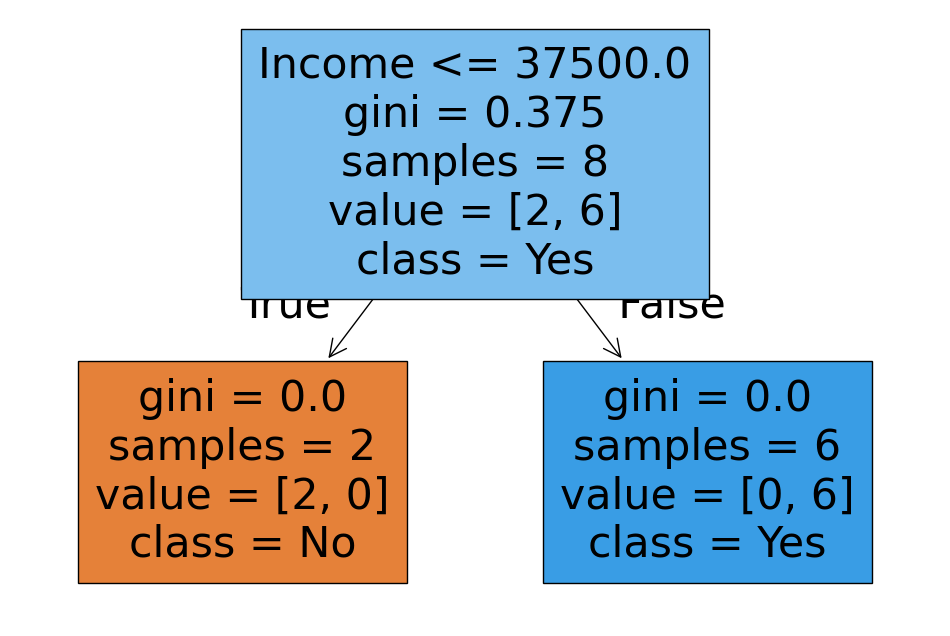

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pandas as pd

data = {
    "Age": [22,25,28,35,40,30,45,50,27,38],
    "Income": [25000,30000,40000,60000,70000,35000,90000,100000,32000,65000],
    "CreditScore": [600,650,700,750,800,680,820,850,640,780],
    "LoanApproved": ["No","No","Yes","Yes","Yes","No","Yes","Yes","No","Yes"]
}

df = pd.DataFrame(data)
encoder = LabelEncoder()

df["LoanApproved"] = encoder.fit_transform(df["LoanApproved"])
X = df[["Age","Income","CreditScore"]]

y = df["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = DecisionTreeClassifier(random_state=42)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

new_customer = [[32,50000,720]]

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")




plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True
)

plt.show()
